# Performance validation for ACA coordinate transform update PR#202

This looks at timing and accuracy.

In [1]:
import sys

sys.path.insert(0, "..")

from chandra_aca import transform
import astropy.table as apt
import matplotlib.pyplot as plt
import matplotlib.style
import numpy as np
matplotlib.style.use("bmh")
# %matplotlib inline

In [2]:
# Configure matplotlib for smaller file sizes
plt.rcParams["figure.dpi"] = 72  # Lower DPI
plt.rcParams["savefig.dpi"] = 72  # Lower DPI for saved figures
%config InlineBackend.figure_format = 'jpg'

### Timing for scalar case

In [3]:
row, col = 100, 200
yag, zag = 1000, 2000


In [4]:
transform.yagzag_to_pixels(yag, zag)
transform.pixels_to_yagzag(row, col);

In [5]:
# %timeit transform.yagzag_to_pixels(yag, zag), flight=True)
# TypeError: yagzag_to_pixels() got an unexpected keyword argument 'flight'

In [6]:
%timeit transform.pixels_to_yagzag(row, col, flight=True)

25.8 μs ± 353 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [7]:
%timeit transform.yagzag_to_pixels(yag, zag)  # flight=False is default

17.6 μs ± 141 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [8]:
%timeit transform.pixels_to_yagzag(row, col, flight=False)

19.9 μs ± 203 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Timing for vector case

In [9]:
row, col = np.linspace(-100, 100, 1000), np.linspace(-200, 200, 1000)
yag, zag = np.linspace(-1000, 1000, 1000), np.linspace(-2000, 2000, 1000)


In [10]:
transform.yagzag_to_pixels(yag, zag)
transform.pixels_to_yagzag(row, col);

In [11]:
# %timeit transform.yagzag_to_pixels(yag, zag), flight=True)
# TypeError: yagzag_to_pixels() got an unexpected keyword argument 'flight'

In [12]:
%timeit transform.pixels_to_yagzag(row, col, flight=True)

62.2 μs ± 1.94 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [13]:
%timeit transform.yagzag_to_pixels(yag, zag)  # flight=False is default

34.7 μs ± 456 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [14]:
%timeit transform.pixels_to_yagzag(row, col, flight=False)

38 μs ± 854 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Accuracy of transforms

In [15]:
star_obss = apt.Table.read("../star_obs_2020.fits.gz")


In [16]:
def dist(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

In [17]:
yag_obss = []
zag_obss = []
for star_obs in star_obss:
    yag_obs, zag_obs = transform.pixels_to_yagzag(
        star_obs["row_obs"], star_obs["col_obs"], t_aca=star_obs["t_aca"], pix_zero_loc="center")
    yag_obss.append(yag_obs)
    zag_obss.append(zag_obs)

In [18]:
dy = yag_obss - star_obss["yag_star"]
dz = zag_obss - star_obss["zag_star"]
print(np.mean(dy), np.mean(dz), np.std(dy), np.std(dz))

0.3647957033916368 0.1558051273496736 0.3947979226811395 0.5590782878705294


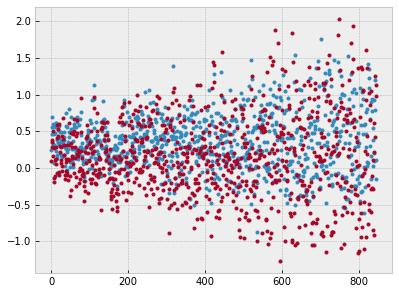

In [19]:
plt.plot(yag_obss - star_obss["yag_star"], '.');
plt.plot(zag_obss - star_obss["zag_star"], '.');

In [20]:
t_aca = 20

In [21]:
yags, zags = np.meshgrid([-2000, 0, 2000], [-2000, 0, 2000])

In [22]:
rows, cols = transform.yagzag_to_pixels(yags, zags) # , t_aca=t_aca)
rows, cols

(array([[ 408.84617918,    5.31857064, -398.45315618],
        [ 408.04787373,    6.08840496, -396.10695594],
        [ 410.36462707,    6.83659696, -396.91909913]]),
 array([[-399.31251093, -397.11002012, -398.13582031],
        [   4.24198442,    4.92618564,    5.57152553],
        [ 407.75361545,  406.91953523,  409.23602337]]))

In [23]:
yags_rt, zags_rt = transform.pixels_to_yagzag(rows, cols, t_aca=t_aca)

In [24]:
yags - yags_rt

array([[-0.04696054, -0.00122451,  0.05886602],
       [ 0.00684844,  0.00290789, -0.00874018],
       [-0.04589014, -0.00115186,  0.05715584]])

In [25]:
zags - zags_rt

array([[-0.04952324,  0.00845695, -0.06068065],
       [ 0.00039118, -0.00084968,  0.00040151],
       [ 0.04640063, -0.00770699,  0.05687825]])

In [26]:
%load_ext line_profiler

In [27]:
row = np.linspace(-100, 100, 1000)
col = np.linspace(-100, 100, 1000)
